<a href="https://colab.research.google.com/github/damyaoferreyra/visualrecommendationsystem/blob/master/visual_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity
import os
import glob
from PIL import Image

In [12]:
# Carregamos o modelo pré-treinado no ImageNet, mas SEM a camada de classificação final (include_top=False)
# Usamos 'avg' (Global Average Pooling) para transformar o mapa de características 2D em um vetor 1D de 1280 dimensões.
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False  # Não vamos treinar a rede, apenas usá-la como extratora

print("Modelo carregado com sucesso! Dimensão do vetor de saída:", base_model.output_shape)

Modelo carregado com sucesso! Dimensão do vetor de saída: (None, 1280)


In [13]:
def extrair_caracteristicas(img_path, model):
    # Carrega a imagem redimensionando para 224x224 (padrão da MobileNet)
    img = image.load_img(img_path, target_size=(224, 224))

    # Converte a imagem para um array numpy e adiciona a dimensão do batch (1, 224, 224, 3)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Normaliza a imagem de acordo com o esperado pelo modelo
    img_preparada = preprocess_input(img_array)

    # Extrai as características (retorna um vetor de tamanho 1280)
    features = model.predict(img_preparada, verbose=0)
    return features.flatten()

In [14]:
# Criando pastas temporárias de produtos no Colab
!mkdir -p dataset/relogios dataset/camisetas dataset/sapatos

# Baixando imagens de exemplo da internet para testar
# Relógios
!wget -O dataset/relogios/relogio1.jpg https://images.unsplash.com/photo-1523275335684-37898b6baf30?w=300
!wget -O dataset/relogios/relogio2.jpg https://images.unsplash.com/photo-1542496658-e33a6d0d50f6?w=300
# Camisetas
!wget -O dataset/camisetas/camiseta1.jpg https://images.unsplash.com/photo-1521572267360-ee0c2909d518?w=300
!wget -O dataset/camisetas/camiseta2.jpg https://images.unsplash.com/photo-1583743814966-8936f5b7be1a?w=300
# Sapatos / Sneakers
!wget -O dataset/sapatos/sapato1.jpg https://images.unsplash.com/photo-1542291026-7eec264c27ff?w=300
!wget -O dataset/sapatos/sapato2.jpg https://images.unsplash.com/photo-1595950653106-6c9ebd614d3a?w=300

# Lista todos os caminhos das imagens do nosso "e-commerce" fictício
caminhos_imagens = glob.glob("dataset/**/*.jpg", recursive=True)
print(f"Total de produtos catalogados: {len(caminhos_imagens)}")

--2026-07-17 01:03:01--  https://images.unsplash.com/photo-1523275335684-37898b6baf30?w=300
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [image/jpeg]
Saving to: ‘dataset/relogios/relogio1.jpg’

dataset/relogios/re 100%[===================>]   8.15K  --.-KB/s    in 0s      

2026-07-17 01:03:01 (65.8 MB/s) - ‘dataset/relogios/relogio1.jpg’ saved [8342/8342]

--2026-07-17 01:03:02--  https://images.unsplash.com/photo-1542496658-e33a6d0d50f6?w=300
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8784 (8.6K) [image/jpeg]
Saving to: ‘dataset/relogios/relogio2.jpg’

dataset/relog

In [15]:
catalogo_features = []
imagens_validas = []

print("Processando catálogo e extraindo assinaturas visuais...")
for caminho in caminhos_imagens:
    try:
        features = extrair_caracteristicas(caminho, base_model)
        catalogo_features.append(features)
        imagens_validas.append(caminho)
    except Exception as e:
        print(f"Erro ao processar {caminho}: {e}")

# Convertendo para array numpy para facilitar cálculos matemáticos
catalogo_features = np.array(catalogo_features)
print("Catálogo pronto para buscas!")

Processando catálogo e extraindo assinaturas visuais...
Catálogo pronto para buscas!


In [16]:
def recomendar_produtos(caminho_imagem_busca, top_k=3):
    # 1. Extrai o vetor da imagem que o usuário está olhando/buscando
    vetor_busca = extrair_caracteristicas(caminho_imagem_busca, base_model).reshape(1, -1)

    # 2. Calcula a similaridade de cosseno entre a busca e todo o catálogo
    similaridades = cosine_similarity(vetor_busca, catalogo_features).flatten()

    # 3. Ordena os índices do maior para o menor grau de similaridade
    indices_ordenados = np.argsort(similaridades)[::-1]

    # Plotando os resultados
    plt.figure(figsize=(15, 5))

    # Mostrar imagem de busca
    plt.subplot(1, top_k + 1, 1)
    img_busca = Image.open(caminho_imagem_busca)
    plt.imshow(img_busca)
    plt.title("Produto Buscado", color='blue')
    plt.axis('off')

    # Mostrar as K recomendações mais próximas
    for i in range(top_k):
        idx = indices_ordenados[i]
        # Se a imagem mais parecida for ela mesma (caso esteja no catálogo), podemos pular ou exibir.
        # Aqui vamos exibir os mais parecidos independente disso.
        caminho_rec = imagens_validas[idx]
        score = similaridades[idx]

        plt.subplot(1, top_k + 1, i + 2)
        img_rec = Image.open(caminho_rec)
        plt.imshow(img_rec)
        plt.title(f"Rec {i+1}\nSim: {score:.2f}", color='green')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

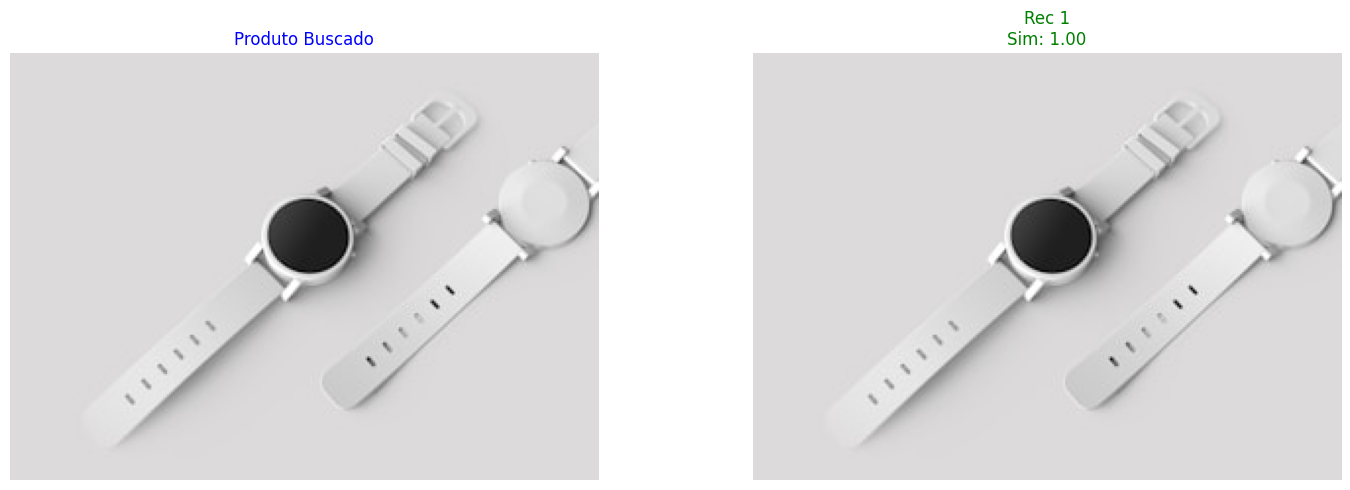

In [26]:
# Vamos testar buscando um sapato (sapato1) e ver se ele nos recomenda outro calçado
imagem_de_teste = "dataset/camisetas/camiseta1.jpg"

imagem_de_teste = "dataset/relogios/relogio1.jpg"
recomendar_produtos(imagem_de_teste, top_k=1)